In [19]:
import numpy as np
import networkx as nx
from grakel import GraphKernel
import matplotlib.pyplot as plt
from torch_geometric.utils import to_networkx

In [20]:
from torch_geometric.datasets import TUDataset
tu_data = TUDataset(root="tutorial1",name= "Yeast")
# https://pytorch-geometrimport networkx as nx
t1 = tu_data[1]
len(t1)

4

In [5]:
G1 = to_networkx(t1, node_attrs=["x"], edge_attrs=["edge_attr"])

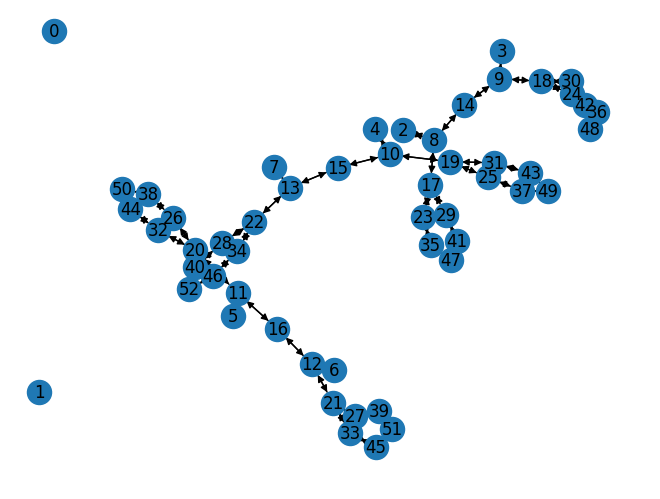

In [6]:
nx.draw(G1, with_labels = True)
plt.show()

In [9]:
UG1 = G1.to_undirected()

In [10]:
connected_components = sorted(nx.connected_components(UG1), key=len, reverse=True)

In [11]:
largest_component = connected_components[0]
second_component = connected_components[1]

In [12]:
 SG1 = G1.subgraph(largest_component)
 SG2 = G1.subgraph(second_component)

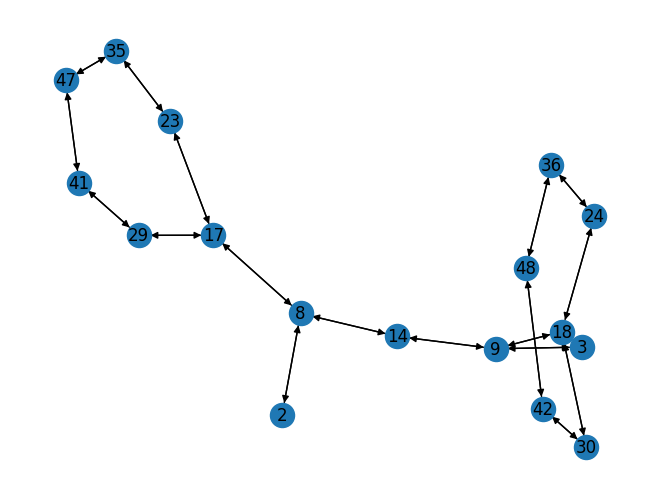

In [13]:
nx.draw(SG1, with_labels = True)
plt.show()

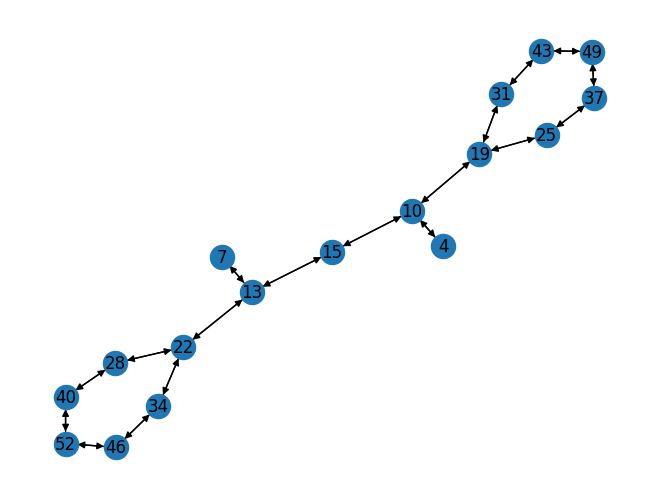

In [15]:
nx.draw(SG2, with_labels = True)
plt.show()

## Calculating eccentricity based on edge weights given as curvatures

In [21]:
# Calculate eccentricity for each node
eccentricities = {}
for node in SG1.nodes():
    # Compute shortest paths considering edge weights (curvatures)
    shortest_paths = nx.single_source_dijkstra_path_length(SG1, node, weight='weight')
    # Eccentricity of a node is the maximum shortest path length
    eccentricity = max(shortest_paths.values())
    eccentricities[node] = eccentricity

print("Eccentricities:", eccentricities)


Eccentricities: {2: 7, 35: 9, 3: 7, 36: 9, 8: 6, 9: 6, 41: 9, 42: 9, 14: 5, 47: 10, 48: 10, 17: 7, 18: 7, 23: 8, 24: 8, 29: 8, 30: 8}


In [22]:
# Calculate eccentricity for each node
eccentricities = {}
for node in SG2.nodes():
    # Compute shortest paths considering edge weights (curvatures)
    shortest_paths = nx.single_source_dijkstra_path_length(SG2, node, weight='weight')
    # Eccentricity of a node is the maximum shortest path length
    eccentricity = max(shortest_paths.values())
    eccentricities[node] = eccentricity

print("Eccentricities:", eccentricities)


Eccentricities: {34: 8, 4: 7, 37: 9, 7: 7, 40: 9, 10: 6, 43: 9, 13: 6, 46: 9, 15: 5, 49: 10, 19: 7, 52: 10, 22: 7, 25: 8, 28: 8, 31: 8}
